In [ ]:
!pip install -q ragas langchain langchain-openai langchain-community langchain-mistralai sentence-transformers psycopg2-binary pgvector langchain_huggingface langchain-postgres

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360.7 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.

In [ ]:
import sys
import types

class DummyVertexAI: pass
class DummyChatVertexAI: pass

dummy_llms = types.ModuleType("langchain_community.llms")
dummy_llms.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms"] = dummy_llms

dummy_chat_models = types.ModuleType("langchain_community.chat_models")
dummy_chat_models.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models"] = dummy_chat_models

dummy_chat_vertexai = types.ModuleType("langchain_community.chat_models.vertexai")
dummy_chat_vertexai.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat_vertexai

dummy_llms_vertexai = types.ModuleType("langchain_community.llms.vertexai")
dummy_llms_vertexai.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms.vertexai"] = dummy_llms_vertexai

In [ ]:
import os
import json
import pandas as pd
import time
import nest_asyncio
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres import PGVector
from langchain_core.prompts import PromptTemplate
from ragas.run_config import RunConfig
from google.colab import userdata, drive

nest_asyncio.apply()

# 1. SETUP
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'
NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

# Mount Google Drive for dataset access
drive.mount('/content/drive')

df = pd.read_csv(DATASET_PATH)

# 2. MODELS & NEW DOCLING DATABASE
print("Connecting to Docling Database and GPT-4o-mini...")
gpt4_mini = ChatOpenAI(model="openai/gpt-4o-mini", api_key=os.environ["OPENROUTER_API_KEY"], base_url="https://openrouter.ai/api/v1", temperature=0)
judge_llm = LangchainLLMWrapper(gpt4_mini)

bge_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={'device': 'cpu'})
ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)

# POINTING TO THE NEW DOCLING COLLECTION
vector_store = PGVector(
    embeddings=bge_embeddings,
    collection_name="awmf_docling_bge",
    connection=NEON_CONNECTION_STRING,
    use_jsonb=True
)
docling_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# 3. PROMPTS
translation_prompt = PromptTemplate(
    template="You are an expert medical translator. Translate the following English medical question into precise German clinical terminology for searching guidelines. Output ONLY the translation and nothing else.\n\nQuestion:\n{question}",
    input_variables=["question"]
)

qa_prompt = PromptTemplate(
    template="You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.\nUse ONLY the provided German context to formulate your answer.\n\nContext (German):\n{context}\n\nQuestion (English):\n{question}\n\nAnswer (English):",
    input_variables=["context", "question"]
)

# 4. GENERATION LOOP
print("\n" + "="*50)
print("STARTING DOCLING GENERATION BATCH...")
print("="*50)

results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

for index, row in df.iterrows():
    english_question = row['English_Open_Question']
    english_ground_truth = row['English_Correct_Text']

    try:
        german_query = gpt4_mini.invoke(translation_prompt.format(question=english_question)).content.strip()

        # Retrieve from DOCLING database
        retrieved_docs = docling_retriever.invoke(german_query)
        contexts = [doc.page_content for doc in retrieved_docs]
        context_string = "\n\n".join(contexts)

        # Generate Answer
        response_msg = gpt4_mini.invoke(qa_prompt.format(context=context_string, question=english_question))

        results["question"].append(english_question)
        results["answer"].append(response_msg.content)
        results["contexts"].append(contexts)
        results["ground_truth"].append(english_ground_truth)

        if (index + 1) % 20 == 0:
            print(f"Progress: {index + 1}/{len(df)} complete.")

        time.sleep(1) # Short sleep since GPT-4 is fast and stable

    except Exception as e:
        print(f"Error at index {index}: {e}")
        continue

# 5. RAGAS EVALUATION
print("\n" + "="*50)
print("GRADING DOCLING PERFORMANCE...")
print("="*50)

eval_features = Features({
    "question": Value("string"),
    "answer": Value("string"),
    "contexts": Sequence(Value("string")),
    "ground_truth": Value("string"),
})

eval_dataset = Dataset.from_dict(results, features=eval_features)

eval_results = evaluate(
    dataset=eval_dataset,
    metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
    llm=judge_llm,
    embeddings=ragas_embeddings,
    run_config=RunConfig(timeout=300, max_workers=2, max_retries=5)
)

res_df = eval_results.to_pandas()
res_df.to_csv(f"{DRIVE_PATH}DOCLING_TEST_gpt-4o-mini_results.csv", index=False)

print("\nDOCLING A/B TEST COMPLETE!")
print("Here are your new scores:")
print(res_df[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean().round(3))

/tmp/ipykernel_1274/3728864516.py:8: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_1274/3728864516.py:8: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_1274/3728864516.py:8: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precis

Mounted at /content/drive
🔌 Connecting to Docling Database and GPT-4o-mini...


/tmp/ipykernel_1274/3728864516.py:34: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  judge_llm = LangchainLLMWrapper(gpt4_mini)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/tmp/ipykernel_1274/3728864516.py:37: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)



STARTING DOCLING GENERATION BATCH...
Progress: 20/200 complete.
Progress: 40/200 complete.
Progress: 60/200 complete.
Progress: 80/200 complete.
Progress: 100/200 complete.
Progress: 120/200 complete.
Progress: 140/200 complete.
Progress: 160/200 complete.
Progress: 180/200 complete.
Progress: 200/200 complete.

GRADING DOCLING PERFORMANCE...


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]


DOCLING A/B TEST COMPLETE!
Here are your new scores:
context_precision    0.119
context_recall       0.183
faithfulness         0.204
answer_relevancy     0.608
dtype: float64


In [2]:
from google.colab import userdata, drive
drive.mount('/content/drive')

Mounted at /content/drive


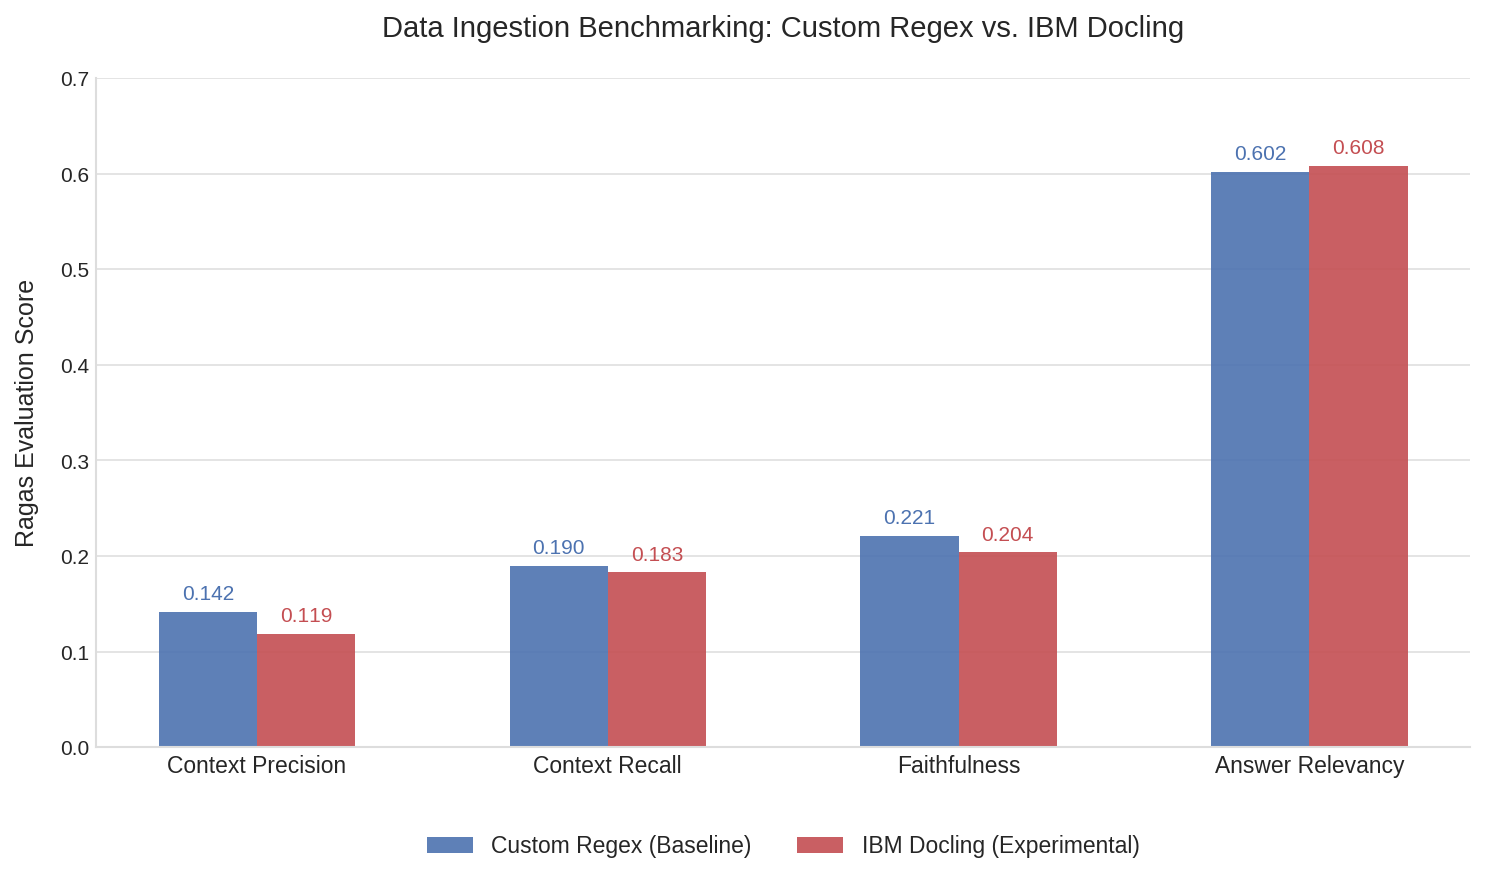

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Data
metrics = ['Context Precision', 'Context Recall', 'Faithfulness', 'Answer Relevancy']
regex_baseline = [0.142, 0.190, 0.221, 0.602]
docling_test = [0.119, 0.183, 0.204, 0.608]

x = np.arange(len(metrics))  # the label locations
width = 0.28  # Slightly thinner bars for a more elegant look

# 2. Plot Setup (Minimalist Academic Style)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Remove background grid lines that clutter the chart, keep only horizontal
ax.grid(axis='y', linestyle='-', alpha=0.4, color='#B0B0B0')
ax.grid(axis='x', visible=False)

# 3. Sophisticated Academic Colors
color_baseline = '#4C72B0'  # Steel Blue
color_docling = '#C44E52'   # Muted Crimson

# 4. Draw the Bars
rects1 = ax.bar(x - width/2, regex_baseline, width, label='Custom Regex (Baseline)', color=color_baseline, alpha=0.9)
rects2 = ax.bar(x + width/2, docling_test, width, label='IBM Docling (Experimental)', color=color_docling, alpha=0.9)

# 5. Clean Formatting and Labels
ax.set_ylabel('Ragas Evaluation Score', fontsize=12, labelpad=10)
ax.set_title('Data Ingestion Benchmarking: Custom Regex vs. IBM Docling', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 0.7)

# Remove top and right spines (borders) for a clean, open look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# 6. Elegant Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11, frameon=False)

# 7. Value Labels (Slightly smaller, matching bar color)
ax.bar_label(rects1, padding=4, fmt='%.3f', fontsize=10, color=color_baseline)
ax.bar_label(rects2, padding=4, fmt='%.3f', fontsize=10, color=color_docling)

plt.tight_layout()

# 8. Save to Drive
plt.savefig('/content/drive/MyDrive/docling_vs_regex_benchmark.png', bbox_inches='tight')
plt.show()